### Introduction to Python and Libraries for Regression, Environmental Setup

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

### Handling missing values, data normalization, standardization, Data visualization using Matplotlib and Seaborn

In [4]:
df = pd.read_csv('data.csv')
df.dropna(inplace=True)


In [5]:
df.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   vidid      14999 non-null  object
 1   adview     14999 non-null  int64 
 2   views      14999 non-null  object
 3   likes      14999 non-null  object
 4   dislikes   14999 non-null  object
 5   comment    14999 non-null  object
 6   published  14999 non-null  object
 7   duration   14999 non-null  object
 8   category   14999 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.0+ MB


In [7]:
df.describe()

,adview
count,1.499900e+04
mean,2.107791e+03
std,5.237711e+04
min,1.000000e+00
25%,1.000000e+00
50%,2.000000e+00
75%,6.000000e+00
max,5.429665e+06


In [8]:
df.tail()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
14994,VID_31,2,525949,1137,83,86,2015-05-18,PT6M10S,A
14995,VID_5861,1,665673,3849,156,569,2015-10-20,PT3M56S,D
14996,VID_805,4,3479,16,1,1,2013-08-23,PT3M13S,B
14997,VID_19843,1,963,0,0,0,2010-10-02,PT26S,G
14998,VID_8534,1,15212,22,5,4,2016-02-19,PT1M1S,D


### Data preprocessing (Correlation, Outlier detection, feature engineering, Data Splitting)

In [10]:
import re
def convert_duration(duration_val):
    if isinstance(duration_val, (int, float)):

        return int(duration_val)
    if isinstance(duration_val, str):
        match = re.match(r'PT(?:(\d+)M)?(?:(\d+)S)?', duration_val)
        if match:
            minutes = int(match.group(1)) if match.group(1) else 0
            seconds = int(match.group(2)) if match.group(2) else 0
            return minutes * 60 + seconds
    return 0
df['duration'] = df['duration'].apply(convert_duration)
df = df.drop(['vidid', 'published', 'category'], axis=1, errors='ignore')

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
X = df.drop('adview', axis=1)
y = df['adview']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(df.dtypes)
print(df.head())

adview      int64
views       int32
likes       int32
dislikes    int32
comment     int32
duration    int64
dtype: object
   adview  views  likes  dislikes  comment  duration
0      40    202   4464       858       81       457
1       2   3343   3631       510     1568       570
2       1   4423   1984         0      628       136
3       6  11575   4282       370      379       262
4       1  12080      1         0        0        31


### Linear Regression, Model evaluation using metrics (R², MAE, MSE)

In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Metrics")
print("R² Score:", r2_score(y_test, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lr))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lr))

Linear Regression Metrics
R² Score: -0.00011476350567596327
Mean Absolute Error: 5169.730711957661
Mean Squared Error: 10760291687.213346


### Visualization: Actual vs Predicted Ad Revenue

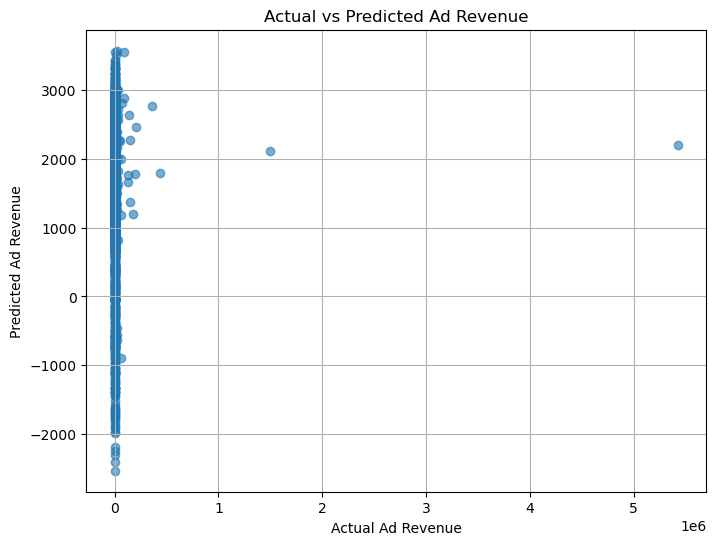

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Ad Revenue")
plt.ylabel("Predicted Ad Revenue")
plt.title("Actual vs Predicted Ad Revenue")
plt.grid(True)
plt.show()

### User Input and Revenue Prediction

In [17]:
views = int(input("Enter number of views: "))
likes = int(input("Enter number of likes: "))
dislikes = int(input("Enter number of dislikes: "))
comments = int(input("Enter number of comments: "))
duration = int(input("Enter video duration in seconds: "))

user_input = pd.DataFrame([[views, likes, dislikes, comments, duration]],
                          columns=X.columns)

predicted_revenue = lr_model.predict(user_input)
print(f"\nPredicted Ad Revenue: ${predicted_revenue[0]:.2f}")

Enter number of views:  1000000
Enter number of likes:  12944
Enter number of dislikes:  334
Enter number of comments:  500
Enter video duration in seconds:  600



Predicted Ad Revenue: $4008.69
